# Calorimetry Python Pre Lab Assignment (5 pts)

**Instructions:**  You are allowed to use any Jupyter Notebooks and/or Gemini to help you do this assignment; however, keep in mind that ***we will be disabling Gemini during lab and you will not have Gemini on any quizzes or exams (but you will have your lab notebook as these quizzes/exams are open notebook).*** Therefore, you should take the time to try to understand the general syntax while doing these assignments by taking notes in your lab notebooks as you've done previously. All concept check interactive quizzes are ungraded and have unlimited attempts.

## Overview

:::{admonition} Overview
This pre-lab assignment will go over Python functions and numerical integration.

**Questions:**
- What is a function in Python?
- How can we do non-linear curve fitting?
- What mathematical functions are appropriate as fitting functions?
- How can we do numerical integration in Python?

**Objectives:**
- Utilize Python functions.
- Fit a non-linear curve using Python.
- Integrate the area under a curve numerically.
:::

## YouTube- Python Functions

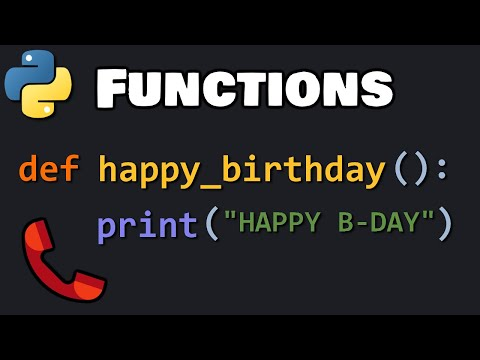

In [1]:
from IPython.display import YouTubeVideo
YouTubeVideo("89cGQjB5R4M",width=640,height=360)

In [2]:
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 14
import numpy as np
import pandas as pd
import scipy
from scipy import integrate

from lmfit import Model

#Quizzes
from IPython.display import display, HTML

%pip install "jupyterquiz"
from jupyterquiz import display_quiz

import sys

# Import package to read Excel files in Jupyter Notebooks (pandas)
%pip install openpyxl 

# Install Jupyter Quiz
%pip install "jupyterquiz" 
from jupyterquiz import display_quiz

sys.path.append('..')  # Add parent directory to path
import quiz_utils      # Now you can import it directly


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## 1.&nbsp;What are Python functions?

Let's first think about functions as we know them from math courses.
Using $f(x)$ as an example, let's use
$$f(x) = 5x+3$$

In Python, we can represent this using a function,

```python
def f(x):
  return 5*x + 3
```

:::{warning} ✏️ Exercise: Working with f(x)
:icon: false
Use `f(x)` by doing the following:

- Copy the code above to define `f(x) = 5x + 3`.
- Calculate `f(0)`, `f(1)`.
- Choose two different numbers (`x1` and `x2`) and calculate `f(x1)` and `f(x2)`.
- Create an array called `xrange` that uses `np.linspace()` to define 11 points from 0 to 10. Then calculate `f(xrange)` and note what happens.
:::

In [3]:
# Insert the code for f(x) here
def f(x):
  return 5*x + 3

In [4]:
# Compute f(0) and f(1)
print("f(0) =", f(0))
print("f(1) =", f(1))

f(0) = 3
f(1) = 8


In [5]:
# Include two new values x1 and x2. Then calculate f(x1) and f(x2).
x1=5
x2=8

print("f(5) =", f(x1))
print("f(8) =", f(x2))

f(5) = 28
f(8) = 43


In [6]:
# Include code for xrange and f(xrange) here.
xrange=np.linspace(0,10,11)
print("f("+str(xrange)+") =",f(xrange))

f([ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]) = [ 3.  8. 13. 18. 23. 28. 33. 38. 43. 48. 53.]


:::{danger} ❓ Question 1
:icon: false
What does it mean for a function to map `x` to `f(x)`? How is defining a function in Python similar to writing a math equation? Include your thoughts and observations below.
:::{warning} 📝 Student Response
:icon: false
To record your response, double click the cell and type your answer after the `>` below!
> <span style="color:red;">When a function maps <code>x</code> to <code>f(x)</code>, it means that for every input <code>x</code>, the function gives one specific output, called <code>f(x)</code>. It's like there's a rule or formula that tells you what to do with <code>x</code>. For example, if <code>f(x) = 2x + 3</code>, then the function takes in <code>x</code> and outputs a new value based on that equation. So if <code>x = 2</code>, then <code>f(x) = 7</code>.</span><br><br>
<span style="color:red;">In Python, we can define the same function like this:</span>

>```python
>def f(x):
>    return 2 * x + 3
>```

> <span style="color:red;">This is really similar to math because it shows the same relationship between <code>x</code> and <code>f(x)</code>. You give the function a number, and it returns the result using the same rule. So in both math and Python, the function is like a machine that takes in <code>x</code> and gives back <code>f(x)</code>.</span><br><br>
>
> <span style="color:red;">Numpy arrays are vectorized. This means that the operations will work as they do for vectors and matrices within linear algebra. In the case of</span> $f(x)$<span style="color:red;">, a vector of</span> $x$ <span style="color:red;">values</span> $[0, 1, 2, 3]$ <span style="color:red;">will yield</span>

>$$f([0,1,2,3]) = 2[0,1,2,3]+3 = [0,2,4,6]+3 = [3,5,7,9]$$
::::::

:::{warning} ✏️ Exercise: Plotting f(x)
:icon: false
Use `f(x)` by doing the following:

- Change the code below to plot $f(x) = -x + 5$.
:::

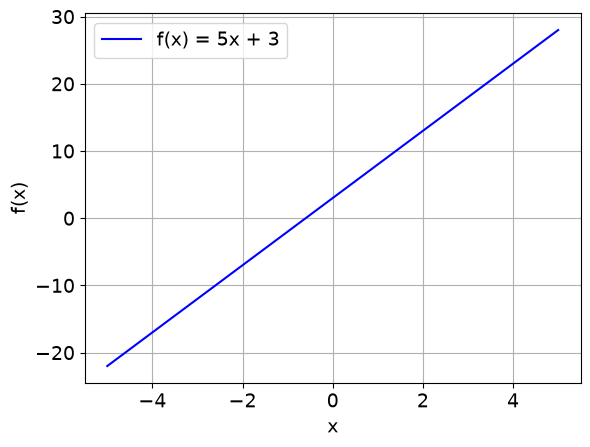

In [7]:
# Define a linear function
def f(x):
    return 5*x + 3

x = np.linspace(-5, 5, 100) # Defines the linear space of x values
y = f(x) # What is the output of this line of code?

# Plotting
plt.plot(x, y, label="f(x) = 5x + 3", color="blue")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()

:::{admonition} Instructor Solution
:class: dropdown

```python
# Define a linear function
def f(x):
    return -x + 5
x = np.linspace(-5, 5, 100) # Defines the linear space of x values
y = f(x) # What is the output of this line of code?
# Plotting
plt.plot(x, y, label="f(x) = -x + 5", color="blue")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()
```
<center> <img width="500"
  src="https://github.com/act-cms/calorimetry-data-analysis/blob/main/01_pre-lab-activity/Figures/linear_prelab.png?raw=true"> 
</center>
:::

## 2.&nbsp;Curve Fitting

In many chemistry and spectroscopy experiments, we collect data that reflects the behavior of physical systems, such as absorbance, emission, or concentration, across a range of variables like time, wavelength, or temperature. However, this data is rarely perfect. Instrumental limitations, environmental fluctuations, and sampling variability often introduce noise.

To setup a curve fitting properly, you need to know all the possible variables that could transform a function. For example, consider a linear function, which is generally represented as $y=mx+b$. A single variable $y=x$ can be transformed through a multiplicative factor ($m$) and either a horizontal ($c$) or vertical ($d$) shift. Using the example of a linear line, a general form would initially look like
\begin{equation*}
	y = m*(x+c)+d
\end{equation*}
and then simplify via algebra to
\begin{equation*}
	y = mx + b
\end{equation*}
where $b = mc + d$.

The main curve fitting package in SciPy is ```curve_fit()```, which has its advantages. We are going to explore using a custom package called ```lmfit``` because it can generate uncertainty estimates. Here is a table explaining the differences between these two curve fitting tools in Python.

<center>

 | Feature                    | `scipy.optimize.curve_fit`     | `lmfit`                  |
| -------------------------- | ------------------------------ | ------------------------------------------------------- |
| **Ease of use**            | Simple and fast                | Slightly more setup, but very flexible                  |
| **Parameter handling**     | Only arrays of parameters      | Named parameters with bounds, constraints               |
| **Bounds**                 | Basic bounds (box constraints) | Full support for bounds and expressions                 |
| **Parameter constraints**  | Not supported                  | Supports tying parameters and expressions             |
| **Fit statistics**         | Minimal (covariance matrix)    | Rich diagnostics (χ², AIC, BIC, uncertainties)          |
| **Fitting engine**         | Levenberg-Marquardt (default)  | Several engines: Levenberg-Marquardt, Nelder-Mead, etc. |
| **Error estimation**       | Covariance matrix only         | Confidence intervals, uncertainties, correlations       |
| **Model reusability**      | None                           | Can reuse and compose models                            |

</center>

:::{warning} ✏️ Exercise: Fitting noisy data
:icon: false
Fit the data in the following graph of noisy data from 0 to 6.3 ($2\pi$).

<center> <img width="300"
  src="https://github.com/act-cms/calorimetry-data-analysis/blob/main/01_pre-lab-activity/Figures/noisy_data_plot_prelab.png?raw=True"> 
</center>

- Use `df.loc[]` to create a slice of the data from 0 to 6.3.
- Include the code for a generic version of a sine function.
- See how the LMFIT package operates as we will be using this for curve fitting.
:::

:::{hint} 🐍 **Why fit data?**
:icon: false

Curve fitting helps us extract meaningful parameters from experimental data by modeling it with a mathematical function. Instead of focusing on every single point, which may be influenced by noise, we fit a trend that reflects the underlying physical process.
:::

In [8]:
noisy_data_all=pd.read_csv('Sample-Data/CurveFitting_SampleData.csv',index_col='x')
noisy_data_all

,y
x,
0.000000,0.882026
0.031574,0.294737
0.063148,0.678309
0.094721,1.402914
0.126295,1.308648
...,...
9.849830,0.845649
9.887372,1.007341
9.924915,1.253517


:::{hint} 🐍 **Slices**
:icon: false


Remember slices from the previous tutorials? We can use those here to filter the data by the x values (index) using `loc` in dataframes.
:::

In [9]:
noisy_data=noisy_data_all.loc[0:6.3]
noisy_data

,y
x,
0.000000,0.882026
0.031574,0.294737
0.063148,0.678309
0.094721,1.402914
0.126295,1.308648
...,...
6.188464,0.103428
6.220038,0.222813
6.251612,0.986960


### Concept Check

In [10]:
quiz_utils.json_to_quiz('../rotation2.json',"pre-lab-quiz-1")

<IPython.core.display.Javascript object>

In [11]:
def sine(x,a,b,c):
  '''The generic version of sine(x)'''
  # You define the generic version of sin(x)
  func = a*np.sin(b*x)+c
  return func

:::{admonition} Note to Instructor
:class: dropdown

The LMFIT package was chosen over `scipy.curve_fit` because the fit report generates the absolute and relative uncertainties without having to go through how to calculate the errors. The various confidence intervals can also be displayed, which can help quickly visualize how this works to students. Feel free to change this to `curve_fit` if you do not need to worry about uncertainty measurements in the fitting function variables. Here is the same code for curve fitting using `scipy.curve_fit()` instead of `lmfit`:

```python
from scipy.optimize import curve_fit

# Import your initial data
x_data = noisy_data.index
y_data = noisy_data['y']

# Initial guess for parameters (adjust based on your chosen function and data)
# It's important to provide reasonable initial guesses for better fitting
initial_guess = [1.0, 1.0, 1.0]

# Perform the curve fitting
params, covariance = curve_fit(sine, x_data, y_data, p0=initial_guess)

# The optimized parameters are in 'params'
print("Optimized parameters:", params)

# You can now use the optimized parameters to plot the fitted curve
x_fit = np.linspace(x_data.min(), x_data.max(), 100)
y_fit = sine(x_fit, *params)
plt.figure(figsize=(8, 5))
plt.scatter(x_data, y_data, label='Noisy Data', s=10)
plt.plot(x_fit, y_fit, label='Fitted Curve', color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Curve Fitting Noisy Data')
plt.legend()
plt.grid(True)
plt.show()
```
:::

In [12]:
# Fit the data with initial conditions
gmodel1 = Model(sine)

xdata=noisy_data.index
ydata=noisy_data['y']

# setting initial values of a, b, and c
result1 = gmodel1.fit(ydata, x=xdata,a=1,b=1,c=0.5)

# Print the standard statistics of the fitting
print(result1.fit_report())

# Print the confidence interval values for each parameter
print(result1.ci_report())

[[Model]]
    Model(sine)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 37
    # data points      = 201
    # variables        = 3
    chi-square         = 50.8989104
    reduced chi-square = 0.25706520
    Akaike info crit   = -270.066142
    Bayesian info crit = -260.156227
    R-squared          = 0.83554658
[[Variables]]
    a:  1.61901241 +/- 0.05114071 (3.16%) (init = 1)
    b:  2.01758732 +/- 0.00835077 (0.41%) (init = 1)
    c:  0.03849986 +/- 0.03578816 (92.96%) (init = 0.5)
      99.73%    95.45%    68.27%    _BEST_    68.27%    95.45%    99.73%
 a:  -0.15535  -0.10291  -0.05127   1.61901  +0.05127  +0.10294  +0.15540
 b:  -0.02527  -0.01666  -0.00826   2.01759  +0.00822  +0.01645  +0.02479
 c:  -0.10874  -0.07203  -0.03588   0.03850  +0.03588  +0.07203  +0.10873


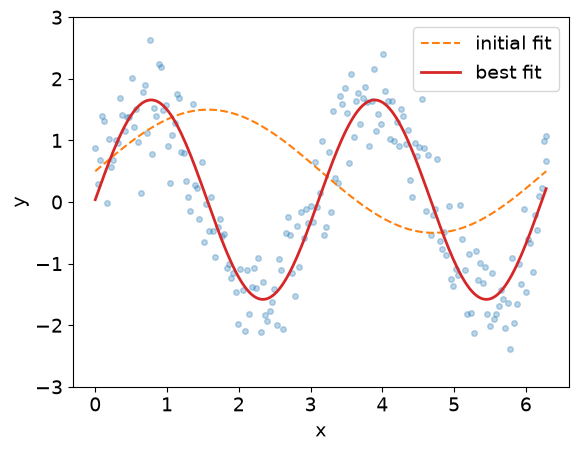

In [13]:
plt.plot(xdata,ydata,'o',alpha=0.3,markersize=4)
plt.plot(xdata, result1.init_fit, '--', label='initial fit')
plt.plot(xdata, result1.best_fit, '-', label='best fit',color='C3',lw=2)
plt.ylim(-3,3)
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc=0)
plt.show()

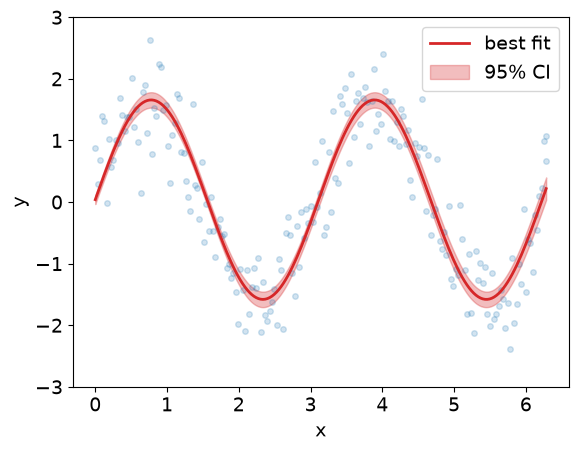

In [14]:
# How to extract the best fit parameters for each variable
A=result1.params['a'].value
B=result1.params['b'].value
C=result1.params['c'].value

# make finely spaced grid of duration values, extending past data range
xfine = np.linspace(0, 2*np.pi, 6501)

# compute the values of the fitted function on the fine grid using a built-in function
yfine = result1.eval(x=xfine)

# Alternatively using the best fit parameters, use your function definitions
# y2 = sine(xfine,A,B,C)

# now calculate uncertainty interval and predicted interval for sigma=2, 95% level
efine = result1.eval_uncertainty(x=xfine, sigma=2)

plt.plot(xdata,ydata,'o',alpha=0.2,markersize=4)
plt.plot(xdata, result1.best_fit, '-', label='best fit',color='C3',lw=2)
plt.fill_between(xfine, yfine-efine, yfine+efine,
                 color="C3", label='95% CI',alpha=0.3)
plt.ylim(-3,3)
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc=0)
plt.show()

### Concept Check

In [15]:
quiz_utils.json_to_quiz('../rotation2.json',"pre-lab-quiz-2")

<IPython.core.display.Javascript object>

:::{danger} ❓ Question 2
:icon: false
Interpret what the cells in this Curve Fitting section does. What are the resulting reports and figures made? Provide your answer below.
:::{warning} 📝 Student Response
:icon: false
To record your response, double click the cell and type your answer after the `>` below!
> <span style="color:red;">The data gets imported as <code>noisy_data</code>. The data is that of a noisy sine-like (sinusoidal) function.</span>
>
><span style="color:red;">We then define the general sine function,</span>
>
$$a\cdot\sin(b\cdot x)+c$$
>
> <span style="color:red;">so that we can fit</span> $a$<span style="color:red;">,</span> $b$<span style="color:red;">, and</span> $c$<span style="color:red;">.</span>
>
> <span style="color:red;">The <code>lmfit</code> package is used to create a fitting model of the generalized sine function. There are initial parameters that we select to fit the function — these choices were plotted as an orange dashed line in the first figure. The best fit parameters are plotted as a red solid line.</span>
>
><span style="color:red;">The fit report and the CI report generates a report that prints the best fit parameters along with the uncertainties (</span>$1\sigma$<span style="color:red;">). The CI report showcases the ranges for</span> $2\sigma$ <span style="color:red;">(95% CI) and</span> $3\sigma$ <span style="color:red;">(99.7% CI).</span>
>
><span style="color:red;">The uncertainty in each parameter is plotted as a <code>plt.fill_between()</code> plot between</span> $x+\Delta_{95\%}x$ <span style="color:red;">and</span> $x-\Delta_{95\%}x$<span style="color:red;">.</span></li>

::::::

## 3.&nbsp;Numerical Integration

When working with functions that don't have easy analytical integrals or when dealing with real-world data, numerical integration becomes essential. Several methods exist to approximate the area under a curve, each with different assumptions, advantages, and accuracy levels.

One commonly used method in Python is ```scipy.integrate.quad()```, which applies adaptive quadrature. To better understand where this method fits in the landscape of numerical integration, lets's compare this method with the Trapezoidal and Simpson's rules that you learned in Calculus.

Below is a figure using three different models (Trapezoid, Simpson, Quad) to solve the following integral

$$\int_{-2}^{2}2xsin(x^2)+x^4-2x^2+1 dx = 6.1\bar{3}$$

<div>
  <center> <img width="1200" src="https://github.com/act-cms/calorimetry-data-analysis/blob/main/01_pre-lab-activity/Figures/Numerical_Integration.png?raw=true"> </center>
</div>

The table below summarizes the key differences between these methods:

<center>

| Feature                  | Trapezoidal Rule                     | Simpson's Rule                                                 | `quad()` (SciPy)                                             |
| ------------------------ | ------------------------------------ | -------------------------------------------------------------- | ------------------------------------------------------------ |
| **Accuracy**             | Lower, especially with curvature     | Medium-high, depends on smoothness                             | High, adaptive to function shape                             |
| **Method**               | Linear interpolation between points  | Polynomial fitting (parabolic segments)                        | Adaptive quadrature using Gaussian methods and error control |
| **Error Control**        | No built-in control                  | No built-in control                                            | Yes (returns estimated error)                                |
| **Function Evaluations** | Fixed at evenly spaced intervals     | Fixed at evenly spaced intervals                               | Dynamic and efficient (refines where needed)                 |
| **Best For**             | Simple, linear-like behavior         | Smooth, predictable functions                                  | Complex or unknown function behavior                         |
| **SciPy Implementation** | `scipy.integrate.trapezoid()`            | `scipy.integrate.simpson()`                                      | `scipy.integrate.quad()`                                     |
| **Data Requirements**    | Function values at any set of points | Function values at evenly spaced points (even number required) | Just a function and limits of integration                    |

</center>


:::{warning} ✏️ Exercise: Integrating g(x)
:icon: false
Calculate the following integral using the trapezoidal, Simpson's, and quad numerical integration scipy functions:

$$\int_{-3}^{3}g(x)dx=\int_{-3}^{3}\dfrac{1}{1+x^2}+\sin(x)\cos(x)\,dx$$

- Change the number of rectangles used in the trapezoidal and Simpson's rule by changing `num_rectangles`.
- Run the cell below to compute the integral of $g(x)$ using each method.
:::

Trapezoidal rule integral: 2.497941643215479
Simpson's rule integral: 2.498058401401262
Quad integral: 2.4980915447965235
Quad estimated error: 1.472607399688446e-08


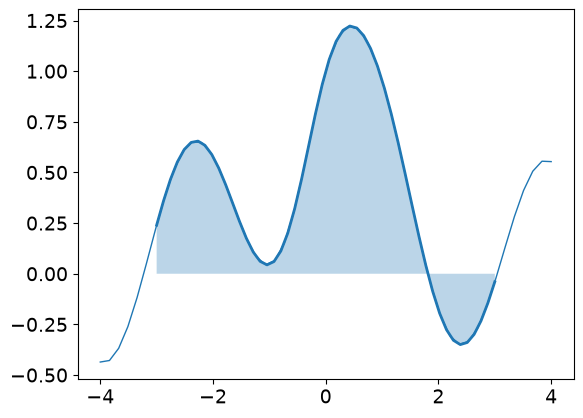

In [17]:
# Define the function g(x)
def g(x):
    return 1 / (1 + x**2) + np.sin(x)*np.cos(x)

# Choose the number of rectangles used for trapezoidal and Simpson's rules
num_rectangles= 50

# Define the integration limits
a = -3
b = 3

# Generate x values for trapezoidal and Simpson's rules
x = np.linspace(a, b, num_rectangles)
X = np.linspace(-4,4, num_rectangles)
y = g(x)

plt.plot(X,g(X),color='C0',lw=1)
plt.plot(x,y,color='C0',lw=2)
plt.fill_between(x,np.zeros(len(y)),y,alpha=0.3)

# Trapezoidal rule
trapz_integral = scipy.integrate.trapezoid(y, x)
print(f"Trapezoidal rule integral: {trapz_integral}")

# Simpson's rule
simps_integral = scipy.integrate.simpson(y, x)
print(f"Simpson's rule integral: {simps_integral}")

# Quad function
quad_integral, quad_error = scipy.integrate.quad(g, a, b)
print(f"Quad integral: {quad_integral}")
print(f"Quad estimated error: {quad_error}")

:::{danger} ❓ Question 3
:icon: false
- What are the main requirements to use these scipy functions?
- When would we prefer numerical integration over analytical solutions?
- Which of the three numerical integration techniques do you think we should use on our thermogram data?
- What happens to each solution as you increase `num_rectangles`?
:::{warning} 📝 Student Response
:icon: false
To record your response, double click the cell and type your answer after the `>` below!
> <span style="color:red;">The main requirement to use these integration scipy functions is the x and y data.</span>
> 
> <span style="color:red;">We would want to use numerical integration over analytical solutions in the case where there is no easy analytical solution to fitting the function.</span>
> 
> <span style="color:red;">We should use <code>scipy.integrate.quad()</code> because that method is adaptive and is not dependent on the number of rectangles to get the integral. The errors were also really small</span> $(1\times10^{-13})$<span style="color:red;">.</span>
> 
><span style="color:red;">The solutions to the trapezoidal and Simpson's rule start to approach the quad value, which is consistent with the analytical solution to</span>
>
> $$\int_{-3}^{3}g(x)dx=\int_{-3}^{3}\dfrac{1}{1+x^2}+\sin(x)\cos(x)\,dx$$
::::::

## 4.&nbsp;Reflections

:::{danger} ❓ Question 4
:icon: false
**Reflection: Where Might You Use Curve Fitting?**

Think about the types of data you encounter in lab experiments or research. Where could curve fitting be applied?

- Have you ever needed to extract peak positions from a **UV-Vis** or **IR** spectrum?
- Have you measured how concentration changes over time in a **kinetics experiment**?
- Have you measured how enzyme reaction rates vary with substrate concentration in a **Michaelis-Menten enzyme kinetics experiment**?
- Have you analyzed **titration curves** to identify the equivalence point or estimate the pK$_a$?

Discuss or write down one example from your own lab or coursework where curve fitting could help clarify or quantify a result.
:::{warning} 📝 Student Response
:icon: false
To record your response, double click the cell and type your answer after the `>` below!
> _Type your answer here!_
::::::

:::{danger} ❓ Question 5
:icon: false
What did you find most challenging in this notebook?
:::{warning} 📝 Student Response
:icon: false
To record your response, double click the cell and type your answer after the `>` below!
> _Type your answer here!_
::::::

:::{admonition} Key Points
- Recognize function notation and Python functions.
- Plot and interpret mathematical models.
- Practice with nonlinear regression.
- Introduce numerical integration methods.
:::